In [7]:
import sys

sys.path.append("../../..")

import torch
import numpy as np
from collections import Counter
from dataloaders.net import VariantRandomDistributionSampler
from dataloaders.csv_log import CSVEventLogDataset
from dataloaders.xes_log import XESEventLogDataset
from dataloaders.runs import RunDataset, AlignerSpec, SimplePerturbedTraceSampler
from dataloaders.net import ProcessModelDataset
from pm4py.discovery import discover_petri_net_inductive
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

parsing log, completed traces :: 100%|██████████| 100000/100000 [00:12<00:00, 8025.52it/s]


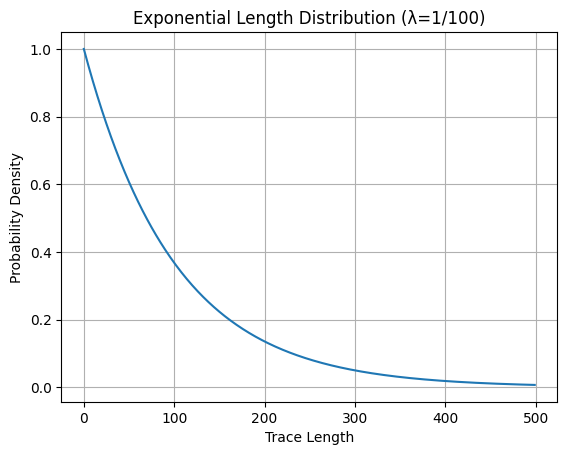

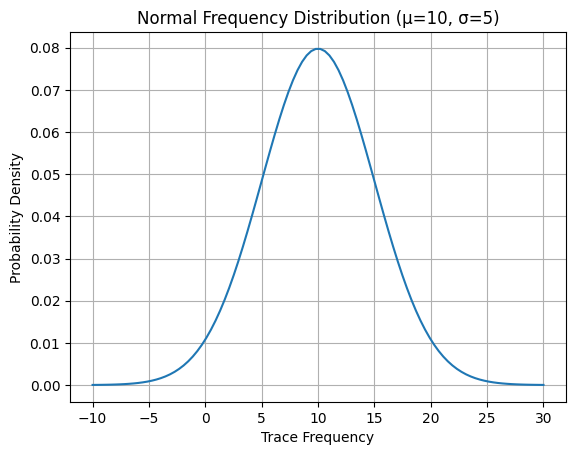

INFO:root:Total discovery configurations generated: 200
INFO:root:Populating process model cache...
Caching discovered models: 0it [00:00, ?it/s]
INFO:root:Cache population done (1628 models).
INFO:root:Populating run dataset cache using 12 workers...














































































































































































































































































































































































































































































































































































































































































































































































In [ ]:
PLOT = True
N_RUNS = 5  # set number of runs here
path = "../../../data/6af6d5f0-f44c-49be-aac8-8eaa5fe4f6fd/Hospital%20Billing%20-%20Event%20Log.xes"

log_dataset = XESEventLogDataset(path)

# subset length distribution: defines the distribution of lengths across samples
len_distribution = torch.distributions.Exponential(
    torch.tensor([1.0 / 100.0])
)
mean, std = 10.0, 5.0
freq_distribution = torch.distributions.Normal(
    mean, std
)  # defines the reordering of traces by defining the sampling distribution over index(index)

if PLOT:
    # plot length distribution
    lengths = torch.arange(0, 500)
    probs = torch.exp(-len_distribution.rate * lengths)
    plt.plot(lengths.numpy(), probs.numpy())
    plt.title("Exponential Length Distribution (λ=1/100)")
    plt.xlabel("Trace Length")
    plt.ylabel("Probability Density")
    plt.grid()
    plt.show()

    # plot frequency distribution
    x = torch.linspace(-10, 30, 100)
    coeff = 1.0 / (std * torch.sqrt(torch.tensor(2.0 * 3.141592653589793)))
    exponent = -0.5 * ((x - mean) / std) ** 2
    probs = coeff * torch.exp(exponent)
    plt.plot(x.numpy(), probs.numpy())
    plt.title("Normal Frequency Distribution (μ=10, σ=5)")
    plt.xlabel("Trace Frequency")
    plt.ylabel("Probability Density")
    plt.grid()
    plt.show()

pm_dataset = ProcessModelDataset(
    log_dataset=log_dataset,
    discovery_methods={"inductive": discover_petri_net_inductive},
    param_grid={
        "noise_threshold": [0.0, 0.1, 0.2, 0.3],
        "disable_fallthroughs": [True],
    },
    sampler_specs={
        "variant3": VariantRandomDistributionSampler(
            n_subsets=50,  # number of subsets: defines how often the log is sampled... basically
            max_len_subset=150,
            min_len_subset=20,  # max_length_subset: limits the possible length of each sample (what is fed to the discovery algorithm)
            len_distribution=len_distribution,
            freq_distribution=freq_distribution,
        )
    },
    cached=True,
)

run_dataset = RunDataset(
    Path('../../../data/runs'),
    pm_dataset,
    AlignerSpec.A_STAR.value,
    SimplePerturbedTraceSampler,
    n_runs=N_RUNS,
    multiprocessing=True,
    slice=range(0, 50),  # <- for testing
)

100%|██████████| 40000/40000 [23:25<00:00, 28.46it/s]  


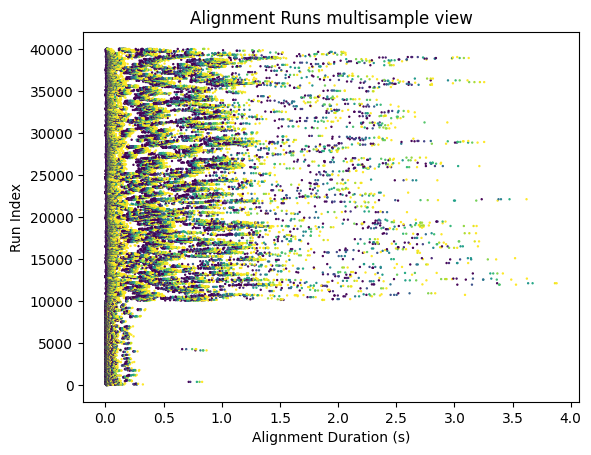

In [ ]:
from tqdm import tqdm
total = len(run_dataset)
label_to_color = {'Variants.VERSION_DIJKSTRA_LESS_MEMORY': 'red',
                'Variants.VERSION_STATE_EQUATION_A_STAR_ILP': 'blue',
                'Variants.VERSION_STATE_EQUATION_A_STAR': 'green',
                'Variants.VERSION_INCREMENTAL_A_STAR': 'yellow'
                }

for i, item in tqdm(enumerate(run_dataset), total=total):
    plt.scatter([p.duration for p in item.perf], [i] * len(item.perf), c=[p.duration for p in item.perf], cmap='viridis', s=0.5)

plt.title("Alignment Runs multisample view")
plt.xlabel("Alignment Duration (s)")
plt.ylabel("Run Index")
plt.show()

  0%|          | 0/40000 [00:00<?, ?it/s]/var/folders/9_/r8063ml13sb8gvbk3gkb_l0w0000gn/T/ipykernel_64896/2674731256.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter([p.duration for p in item.perf], [i] * len(item.perf), c=[label_to_color[item.algo]] * len(item.perf), cmap='viridis', s=0.4, alpha=0.5)
100%|██████████| 40000/40000 [24:47<00:00, 26.90it/s]   


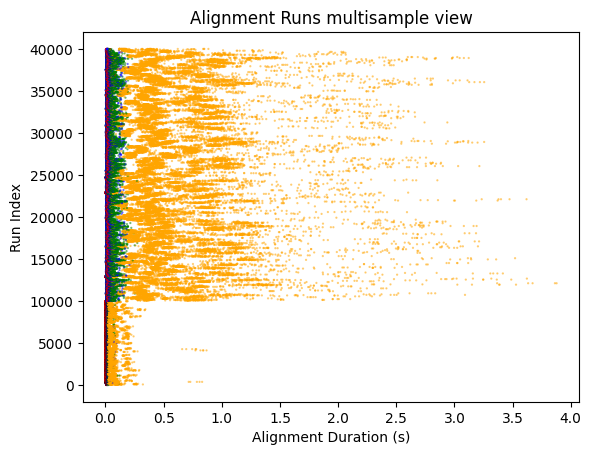

In [26]:
from tqdm import tqdm
total = len(run_dataset)
label_to_color = {'Variants.VERSION_DIJKSTRA_LESS_MEMORY': 'red',
                'Variants.VERSION_STATE_EQUATION_A_STAR_ILP': 'blue',
                'Variants.VERSION_STATE_EQUATION_A_STAR': 'green',
                'Variants.VERSION_INCREMENTAL_A_STAR': 'orange'
                }

for i, item in tqdm(enumerate(run_dataset), total=total):
    plt.scatter([p.duration for p in item.perf], [i] * len(item.perf), c=[label_to_color[item.algo]] * len(item.perf), cmap='viridis', s=0.4, alpha=0.5)

plt.title("Alignment Runs multisample view")
plt.xlabel("Alignment Duration (s)")
plt.ylabel("Run Index")
plt.show()

In [13]:
df_l = pd.read_csv('../../../test_labels.csv')
df_l.head()

,item_id,combination_id,model_id,trace_id,aligner,feature_vector,time_total_mean,time_total_std,time_total_median,time_search_mean,time_lp_mean
0,ce651aaca959018b32f1698ed7cdadf4c921f4f6,00000b038ed545657c6f98e19124f1032b0abd03,5dce0940202e1e517a38ece58269880ac616e538,d80eb8c81f67feade7fbebfc95751021349e84dd,Variants.VERSION_DIJKSTRA_LESS_MEMORY,[ 59. 33. 118. 45. ...,0.016191,0.001584,0.015157,0.001352,0.000062
1,568d6d600796af4a406c93448eaed24501857696,00029fbb0e0940c650afdac403aeccab06ade1ba,10a16d9e4b3236f13100a5681d9c38d283b96b1b,33661a5c2f8da273b4f65c19f56d63a51ad09604,Variants.VERSION_DIJKSTRA_LESS_MEMORY,[47. 27. 94. 36. ...,0.016850,0.003780,0.016136,0.001453,0.000061
2,c37f14b8079234cce1a2a41bb7e915b418ba2dcb,0003567a80cd5d3b798cf092052b3954b215eaa1,64bc3d71656eeae700210d2370449ed5367ebcdf,b5b7bb294095623ca558101cd63ed90d48616b7a,Variants.VERSION_DIJKSTRA_LESS_MEMORY,[ 59. 33. 118. 45. ...,0.019273,0.002194,0.019283,0.001335,0.000060
3,314e7d8bb659a88f94ae78791d59c6318c1184b2,0009ea72f3d199e7ef37facc9bd37bff2607841d,bedd766ecc930a2f296e24a5aec9dbd6bd0a90d1,ad4a897f3a7c478ada186d5f18d847736a19e9f1,Variants.VERSION_DIJKSTRA_LESS_MEMORY,[48. 28. 96. 37. ...,0.016826,0.000577,0.016781,0.001183,0.000059
4,f13e6e840a90fabca41ac716a603ca534aa4f5ff,000b6163f10a419c73bc4b0b08da822e8ef431d3,2ba575824e4bb3b4d8d6a2ee7570dc0aa9361361,af78638a9e53fd555ec028fb79c7e95db01997d9,Variants.VERSION_DIJKSTRA_LESS_MEMORY,[29. 12. 58. 13. ...,0.003526,0.000089,0.003540,0.000550,0.000039


/var/folders/9_/r8063ml13sb8gvbk3gkb_l0w0000gn/T/ipykernel_64896/472749730.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(row.time_total_mean, i, c=label_to_color[row.aligner], cmap='viridis', s=0.3)


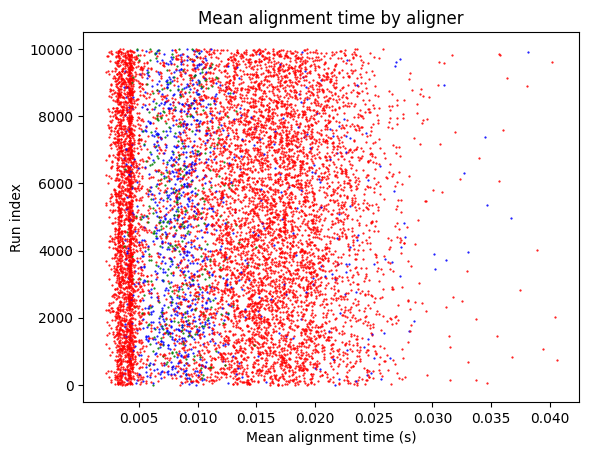

In [21]:
label_to_color = {'Variants.VERSION_DIJKSTRA_LESS_MEMORY': 'red',
                'Variants.VERSION_STATE_EQUATION_A_STAR_ILP': 'blue',
                'Variants.VERSION_STATE_EQUATION_A_STAR': 'green'}
label_to_int = {k: i for i, k in enumerate(label_to_color.keys())}
df_l['label'] = df_l['aligner'].map(label_to_int)

for i, row in enumerate(df_l.itertuples()):
    plt.scatter(row.time_total_mean, i, c=label_to_color[row.aligner], cmap='viridis', s=0.3)

plt.title('Mean alignment time by aligner')
plt.xlabel('Mean alignment time (s)')
plt.ylabel('Run index')
plt.show()

In [16]:
df_l["aligner"].value_counts()

aligner
Variants.VERSION_DIJKSTRA_LESS_MEMORY         8624
Variants.VERSION_STATE_EQUATION_A_STAR_ILP    1006
Variants.VERSION_STATE_EQUATION_A_STAR         370
Name: count, dtype: int64